# 05 · Reconstruir la mezcla desde ruido con un modelo pre-entrenado

Igual que el notebook `02`, pero **sin entrenar acá**: cargamos una red de score ya entrenada
**afuera** (`models/phase_1/vp_mixture.pt`) y la usamos para **reconstruir la mezcla de gaussianas a
partir de una normal** $\mathcal N(0, I)$.

El checkpoint es *model-agnóstico* (guarda `state_dict` + una receta `meta["model"] = {name, kwargs}`),
así que el flujo es:

1. `load_checkpoint` → `(state_dict, meta)`.
2. **Reconstruir** la red con `make_model(meta["model"]…)` y cargarle los pesos.
3. Reconstruir la SDE del checkpoint (`make_sde(meta["sde_name"], …)`).
4. Integrar el **proceso reverso** (Euler–Maruyama) desde el prior $\mathcal N(0,I)$ → mezcla.

Nada se reentrena: la red se consume como función pura $s_\theta(x,t)$ (Eje 2).

In [11]:
# --- Setup: bootstrap de sys.path + imports + defaults de ploteo ---
import sys
import pathlib

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.models import make_model
from diffusion.sde import make_sde
from diffusion.training import load_checkpoint
from diffusion.samplers import make_sampler, available_samplers
from diffusion.data_generation import make_distribution

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("paquete en:", _root)
print("samplers disponibles:", available_samplers())

paquete en: c:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models
samplers disponibles: ['euler', 'heun', 'pc', 'pf_ode']


## Cargar el checkpoint entrenado afuera

`load_checkpoint` devuelve `(state_dict, meta)` **sin reconstruir** la red (es responsabilidad del
caller). Con la receta `meta["model"]` reconstruimos la red vía `make_model`, le cargamos los pesos y
la ponemos en `eval`. La SDE sale de `meta["sde_name"]` / `meta["data_dim"]`.

In [12]:
CKPT = _root / "models" / "phase_1" / "vp_mixture.pt"
assert CKPT.exists(), f"No encontré el checkpoint: {CKPT}"

state_dict, meta = load_checkpoint(CKPT)
recipe = meta["model"]                                  # {"name": ..., "kwargs": {...}}
net = make_model(recipe["name"], **recipe["kwargs"])    # red reconstruida (misma arquitectura)
net.load_state_dict(state_dict)                          # pesos entrenados afuera
net.eval()

sde = make_sde(meta["sde_name"], data_dim=meta["data_dim"])

print(f"checkpoint : {CKPT.relative_to(_root)}")
print(f"SDE        : {meta['sde_name']}  (data_dim={meta['data_dim']}, T={sde.T})")
print(f"red        : {recipe['name']}  kwargs={recipe['kwargs']}  -> {type(net).__name__}")
print(f"history    : {len(meta.get('history', []))} registros"
      + (f"  loss {meta['history'][0]:.4f} -> {meta['history'][-1]:.4f}" if meta.get('history') else ""))

checkpoint : models\phase_1\vp_mixture.pt
SDE        : vp  (data_dim=2, T=1.0)
red        : mlp  kwargs={'embed_dim': 128, 'hidden_dim': 512, 'num_blocks': 4, 'activation': 'silu', 'data_dim': 2}  -> ScoreMLP
history    : 19200 registros  loss 1.1660 -> 0.3019


La curva de pérdida viene **guardada en el checkpoint** (`meta["history"]`), es la traza del
entrenamiento externo — acá no entrenamos, solo la mostramos como referencia.

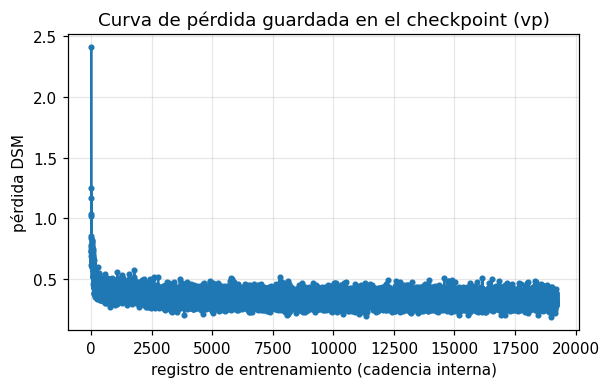

In [13]:
hist = meta.get("history", [])
if hist:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(hist, lw=1.5, marker="o", ms=3)
    ax.set_xlabel("registro de entrenamiento (cadencia interna)")
    ax.set_ylabel("pérdida DSM")
    ax.set_title(f"Curva de pérdida guardada en el checkpoint ({meta['sde_name']})")
    plt.show()
else:
    print("El checkpoint no trae history.")

## El campo de score cargado

Chequeo rápido de que la red cargada es un score razonable: $s_\theta(x,t)$ debe apuntar hacia los
modos de la mezcla a $t$ chico y aplanarse a $t$ grande (idéntico al notebook `02`, pero con la red
que vino del disco).

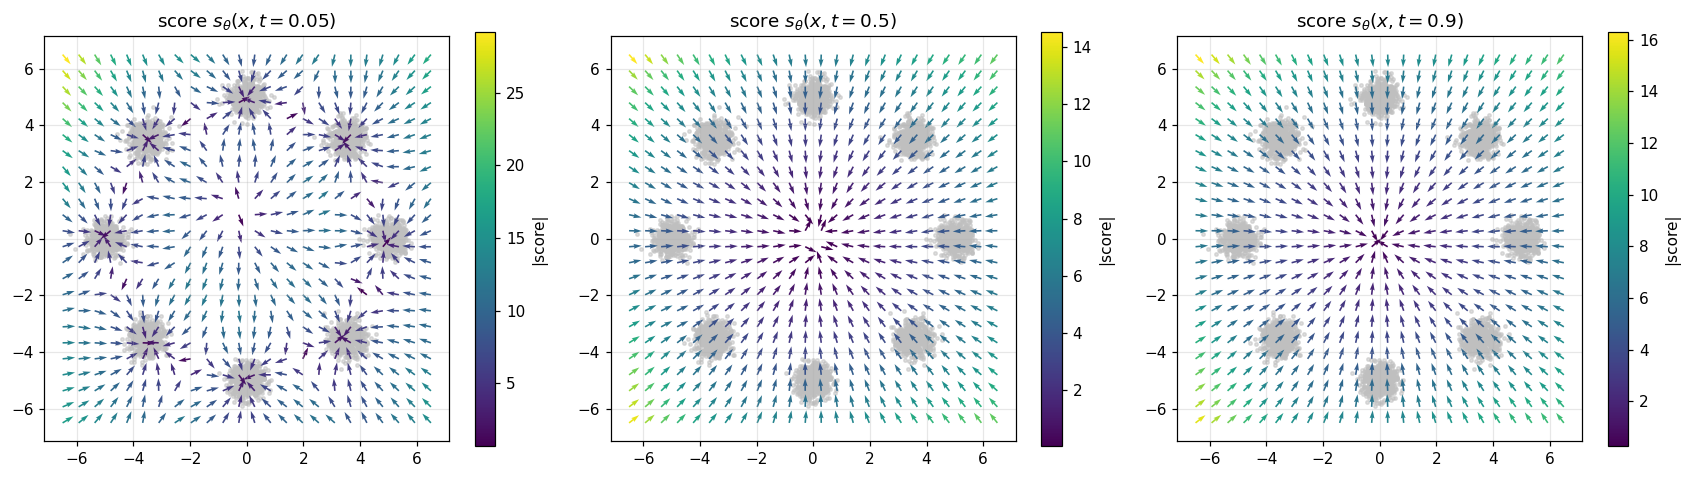

In [14]:
def score_field(net, t_val, lim=2.5, n=24):
    xs = np.linspace(-lim, lim, n)
    gx, gy = np.meshgrid(xs, xs)
    pts = np.stack([gx.ravel(), gy.ravel()], axis=1).astype(np.float32)
    x = torch.from_numpy(pts)
    t = torch.full((x.shape[0],), float(t_val))
    with torch.no_grad():
        s = net(x, t).numpy()
    return gx, gy, s

ref = make_distribution("mixture", dim=2, n_components=8, standardize=False, seed=1)
xd = ref.sample(5000)

t_vals = [0.05, 0.5, 0.9]
fig, axes = plt.subplots(1, len(t_vals), figsize=(5.2 * len(t_vals), 5))
for ax, tv in zip(axes, t_vals):
    gx, gy, s = score_field(net, tv, lim = 6.5)
    mag = np.linalg.norm(s, axis=1)
    u, v = s[:, 0] / (mag + 1e-8), s[:, 1] / (mag + 1e-8)
    ax.scatter(xd[:, 0], xd[:, 1], c="0.75", s=5, alpha=0.5, zorder=0)
    q = ax.quiver(gx.ravel(), gy.ravel(), u, v, mag, cmap="viridis",
                  scale=32, width=0.004, zorder=1)
    ax.set_aspect("equal"); ax.set_title(f"score $s_\\theta(x, t={tv})$")
    fig.colorbar(q, ax=ax, shrink=0.8, label="|score|")
fig.tight_layout()
plt.show()

## Reconstruir la mezcla desde una normal

Arrancamos del prior $x_T\sim\mathcal N(0,I)$ (la "normal") e integramos la SDE reversa
$dx = [f - g^2 s_\theta]\,dt + g\,d\bar W$ con Euler–Maruyama hasta $t_\epsilon$. El resultado $x_0$
debería recuperar la mezcla de 8 gaussianas.

Comparamos tres nubes en la **misma escala**: el prior de entrada, lo generado, y los datos de
referencia.

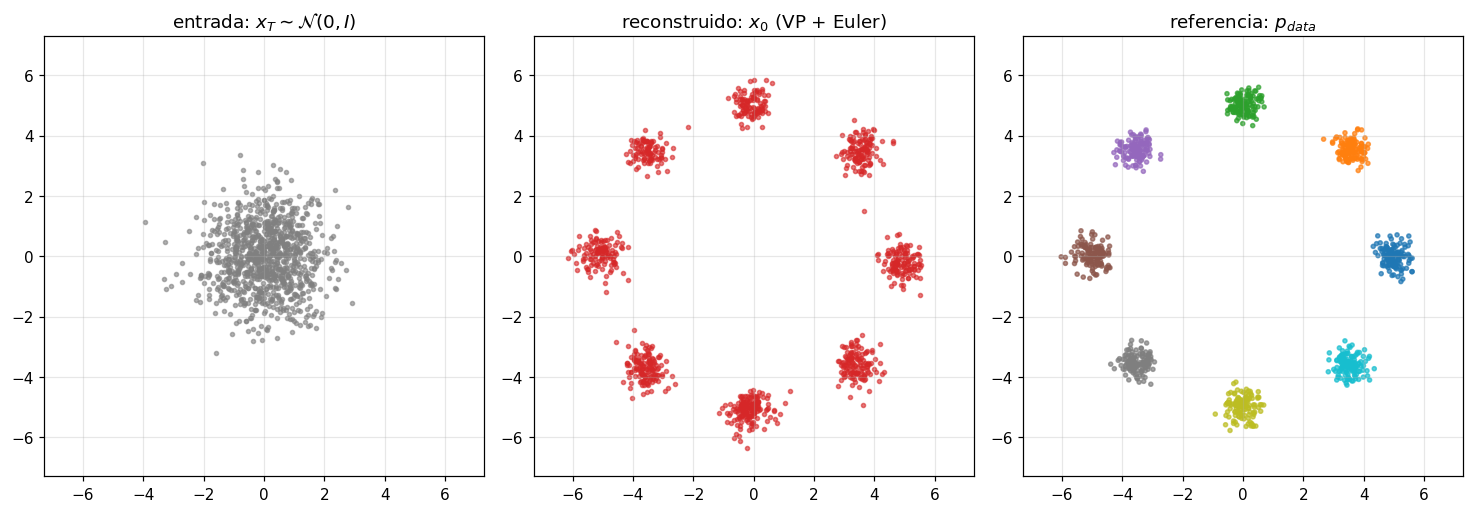

prior     mean/std: [ 0.03  -0.014] [0.996 1.06 ]
generado  mean/std: [-0.037 -0.519] [3.508 3.597]
data      mean/std: [0.005 0.001] [3.549 3.557]


In [18]:
sampler = make_sampler("euler", sde, net, n_steps=500, t_eps=1e-4)

gen = torch.Generator().manual_seed(SEED)
N = 1000
x_prior = sde.prior_sampling((N, sde.data_dim), generator=gen).numpy()   # x_T ~ N(0, I)
x0_gen = sampler.sample(N, generator=gen).numpy()                        # x_0 reconstruido
x0_ref = ref.sample(N)                                                   # p_data de referencia

lim = 1.15 * float(np.abs(np.concatenate([x_prior, x0_gen, x0_ref])).max())
titles = ["entrada: $x_T \\sim \\mathcal{N}(0, I)$",
          "reconstruido: $x_0$ (VP + Euler)",
          "referencia: $p_{data}$"]
clouds = [x_prior, x0_gen, x0_ref]
col = ["0.5", "C3", None]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, cloud, ttl, c in zip(axes, clouds, titles, col):
    if c is None:
        ax.scatter(cloud[:, 0], cloud[:, 1], c=ref.color_, cmap="tab10", s=7, alpha=0.7)
    else:
        ax.scatter(cloud[:, 0], cloud[:, 1], c=c, s=7, alpha=0.6)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal"); ax.set_title(ttl)
fig.tight_layout()
plt.show()

print("prior     mean/std:", np.round(x_prior.mean(0), 3), np.round(x_prior.std(0), 3))
print("generado  mean/std:", np.round(x0_gen.mean(0), 3), np.round(x0_gen.std(0), 3))
print("data      mean/std:", np.round(x0_ref.mean(0), 3), np.round(x0_ref.std(0), 3))

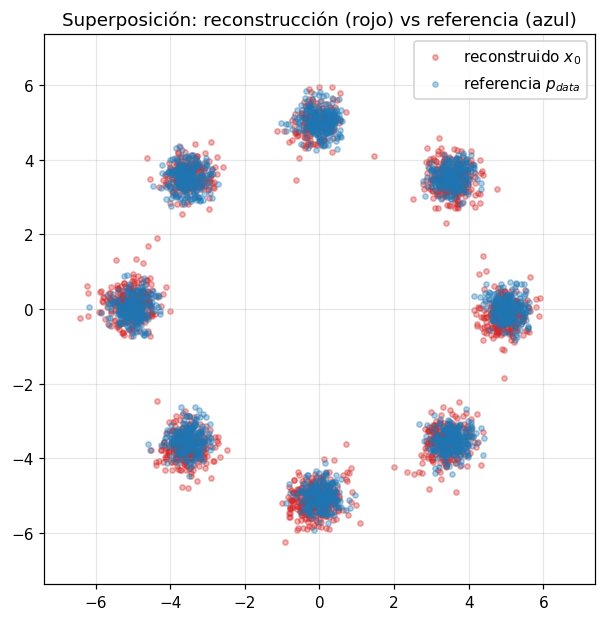

In [ ]:
# "Merge": referencia y reconstrucción superpuestas en los MISMOS ejes, para ver si solapan.
# Ambas nubes semitransparentes: donde coinciden, el azul y el rojo se mezclan (violáceo).
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(x0_gen[:, 0], x0_gen[:, 1], s=12, alpha=0.35, c="C3",
           label="reconstruido $x_0$", zorder=1)
ax.scatter(x0_ref[:, 0], x0_ref[:, 1], s=12, alpha=0.35, c="C0",
           label="referencia $p_{data}$", zorder=2)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_title("Superposición: reconstrucción (rojo) vs referencia (azul)")
plt.show()

## Trayectorias: de la normal a la mezcla

Unas pocas partículas desde el ruido inicial $x_T$ (normal) hasta $x_0$ (mezcla), con
`return_trajectory=True`.

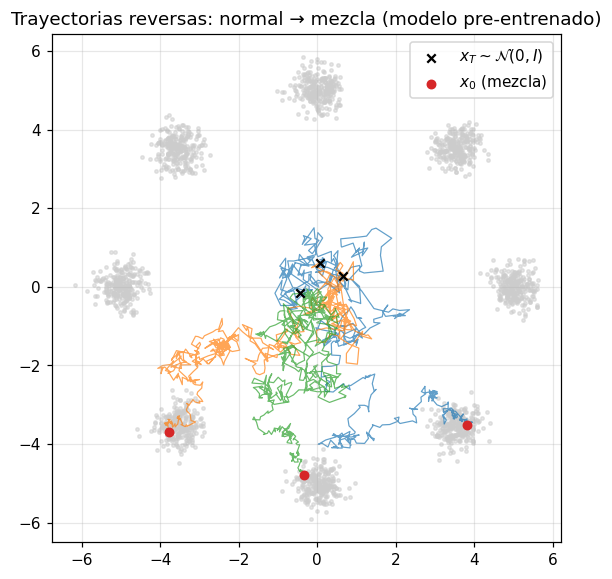

In [ ]:
gen = torch.Generator().manual_seed(SEED)
n_traj = 3
_, traj = sampler.sample(n_traj, generator=gen, return_trajectory=True)
traj = traj.numpy()   # (n_steps+1, n_traj, 2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x0_ref[:, 0], x0_ref[:, 1], c="0.8", s=5, alpha=0.5, zorder=0)
for k in range(n_traj):
    ax.plot(traj[:, k, 0], traj[:, k, 1], lw=0.8, alpha=0.7, zorder=1)
ax.scatter(traj[0, :, 0], traj[0, :, 1], c="k", s=30, marker="x",
           label="$x_T \\sim \\mathcal{N}(0,I)$", zorder=2)
ax.scatter(traj[-1, :, 0], traj[-1, :, 1], c="C3", s=30, label="$x_0$ (mezcla)", zorder=2)
ax.set_aspect("equal"); ax.legend(loc="upper right")
ax.set_title("Trayectorias reversas: normal → mezcla (modelo pre-entrenado)")
plt.show()

## Cierre

- El checkpoint `models/phase_1/vp_mixture.pt` se cargó y reconstruyó sin reentrenar: `load_checkpoint`
  + `make_model` + `load_state_dict`.
- Partiendo de una **normal** $\mathcal N(0,I)$, el proceso reverso (VP + Euler–Maruyama) **reconstruye
  la mezcla de 8 gaussianas**.
- Misma mecánica que el notebook `02`, con la red entrenada afuera en lugar de entrenada inline.

Para barrer los otros samplers (`pf_ode`, `heun`, `pc`) sobre este mismo checkpoint sin reentrenar,
basta cambiar el nombre en `make_sampler` (o usar `diffusion.samplers.generate_from_checkpoint`).